In [1]:
import sys; sys.path.append("../src")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import shap
from xgboost import XGBClassifier

from data_prep import load_merged, temporal_split
from eval_harness import evaluate
from features import (categorical_columns, fit_categories,
                      apply_categories, add_time_features, feature_list)

df = load_merged("../data/raw")
train, val, test = temporal_split(df)
vocab = fit_categories(train, categorical_columns(train))
train = add_time_features(apply_categories(train, vocab))
val   = add_time_features(apply_categories(val, vocab))
feats = feature_list(train)
y_train, y_val = train["isFraud"], val["isFraud"]

model = XGBClassifier(tree_method="hist", eval_metric="logloss", n_jobs=-1,
                      random_state=42, enable_categorical=True)
model.fit(train[feats], y_train)
proba_val = model.predict_proba(val[feats])[:, 1]
r = evaluate(y_val, proba_val, name="repro check")
assert abs(r["pr_auc"] - 0.577) < 0.005, r 
print(r)


{'name': 'repro check', 'pr_auc': 0.577, 'roc_auc': 0.9073, 'threshold': 0.5, 'recall': np.float64(0.3869), 'precision': np.float64(0.7894), 'flagged': 2260, 'missed_fraud': 2827}


In [2]:
# a sample keeps the beeswarm fast; local explanations use full val later
Xs = val[feats].sample(20_000, random_state=0)

explainer = shap.TreeExplainer(model)
sv = explainer(Xs)                     # shap.Explanation object

print("shap matrix:", sv.values.shape)          # (20000, n_features)
print("baseline (log-odds):", sv.base_values[0].round(4))

# LOCAL ACCURACY, verified: baseline + sum(phi) must equal the model's raw margin
margin = model.predict(Xs, output_margin=True)   # raw log-odds output
recon  = sv.base_values + sv.values.sum(axis=1)
print("max reconstruction error:", np.abs(recon - margin).max())   # ~1e-4 or less


shap matrix: (20000, 434)
baseline (log-odds): -4.0344
max reconstruction error: 6.67572e-06


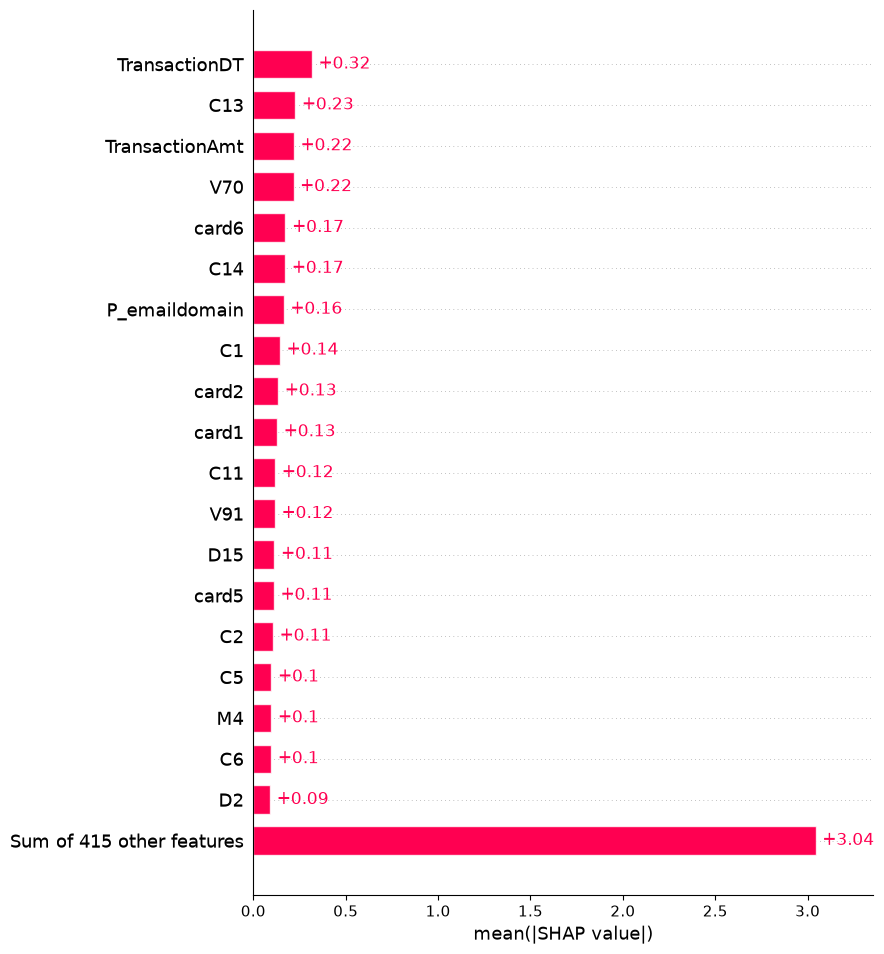

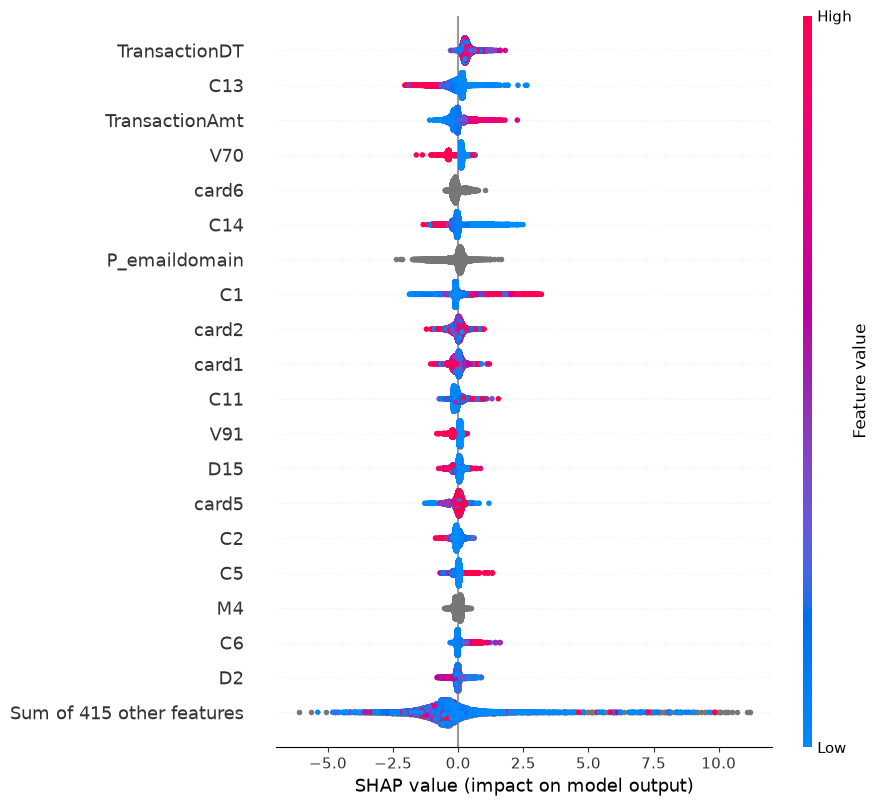

In [8]:
import os
import matplotlib.pyplot as plt
os.makedirs("../reports/figures", exist_ok=True)

shap.plots.bar(sv, max_display=20, show=False)
plt.savefig("../reports/figures/shap_bar.png", dpi=150, bbox_inches="tight")
plt.show()

shap.plots.beeswarm(sv, max_display=20, show=False)
plt.savefig("../reports/figures/shap_beeswarm.png", dpi=150, bbox_inches="tight")
plt.show()


In [9]:
# Does the DT-free model age better? Compare decay across val's two time-halves
from sklearn.metrics import average_precision_score
half = len(val) // 2
y_a, y_b = y_val.iloc[:half], y_val.iloc[half:]
for name, p in [("with DT   ", proba_val), ("without DT", p2)]:
    a = average_precision_score(y_a, p[:half])
    b = average_precision_score(y_b, p[half:])
    print(f"{name}  near-half {a:.4f}   far-half {b:.4f}   decay {a - b:+.4f}")


with DT     near-half 0.6024   far-half 0.5454   decay +0.0570
without DT  near-half 0.5981   far-half 0.5326   decay +0.0656


In [10]:
# The two top claims shared device + amount + email domain. How pure is that pattern?
mask = (val["DeviceInfo"] == "SAMSUNG SM-J701M Build/NRD90M") & (val["TransactionAmt"] == 350)
print(f"{mask.sum()} val claims match device+amount pattern; "
      f"fraud rate among them: {val.loc[mask, 'isFraud'].mean():.2%}")


6 val claims match device+amount pattern; fraud rate among them: 100.00%


In [4]:
feats_nodt = [f for f in feats if f != "TransactionDT"]

m2 = XGBClassifier(tree_method="hist", eval_metric="logloss", n_jobs=-1,
                   random_state=42, enable_categorical=True)
m2.fit(train[feats_nodt], y_train)
p2 = m2.predict_proba(val[feats_nodt])[:, 1]
print(evaluate(y_val, p2, name="without TransactionDT"))
print(evaluate(y_val, proba_val, name="with    TransactionDT"))


{'name': 'without TransactionDT', 'pr_auc': 0.5685, 'roc_auc': 0.9055, 'threshold': 0.5, 'recall': np.float64(0.3715), 'precision': np.float64(0.8181), 'flagged': 2094, 'missed_fraud': 2898}
{'name': 'with    TransactionDT', 'pr_auc': 0.577, 'roc_auc': 0.9073, 'threshold': 0.5, 'recall': np.float64(0.3869), 'precision': np.float64(0.7894), 'flagged': 2260, 'missed_fraud': 2827}



claim TransactionID=3355806, P(fraud)=1.000, actually fraud: True


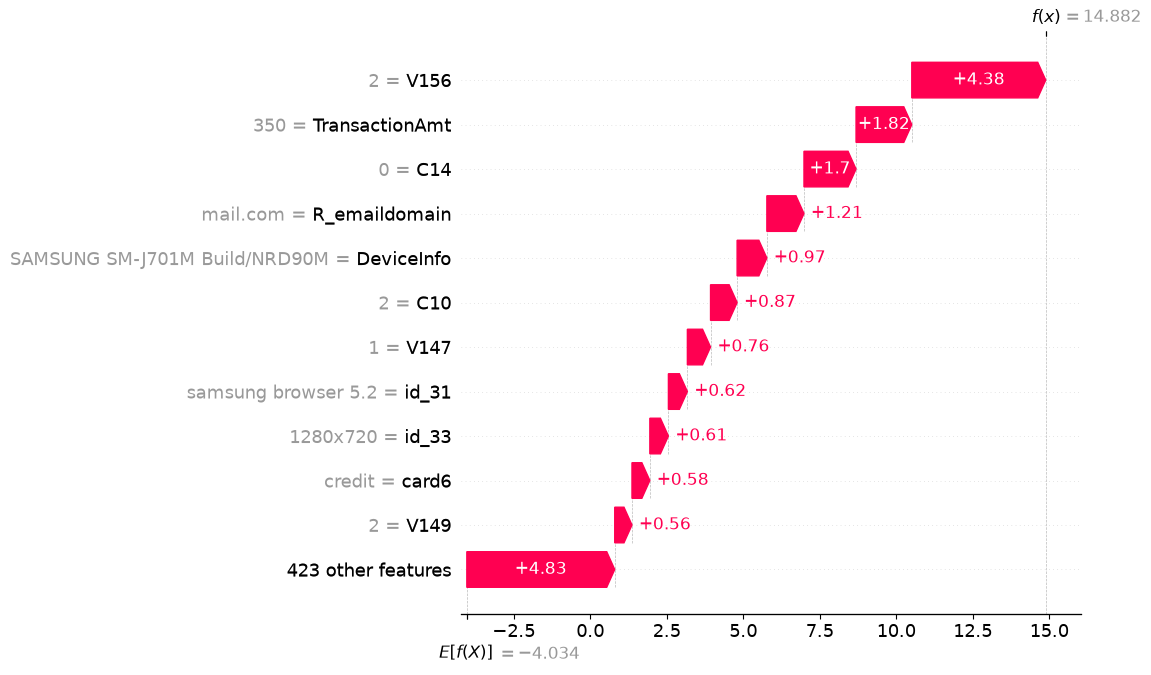


claim TransactionID=3355882, P(fraud)=1.000, actually fraud: True


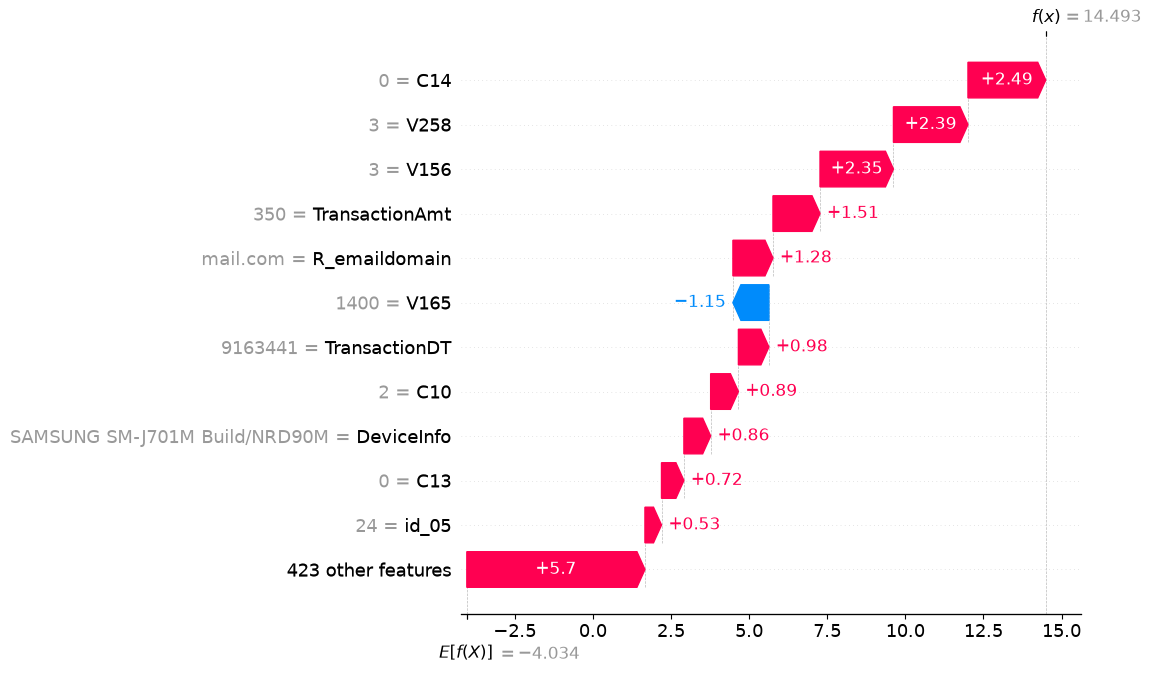


claim TransactionID=3406492, P(fraud)=1.000, actually fraud: True


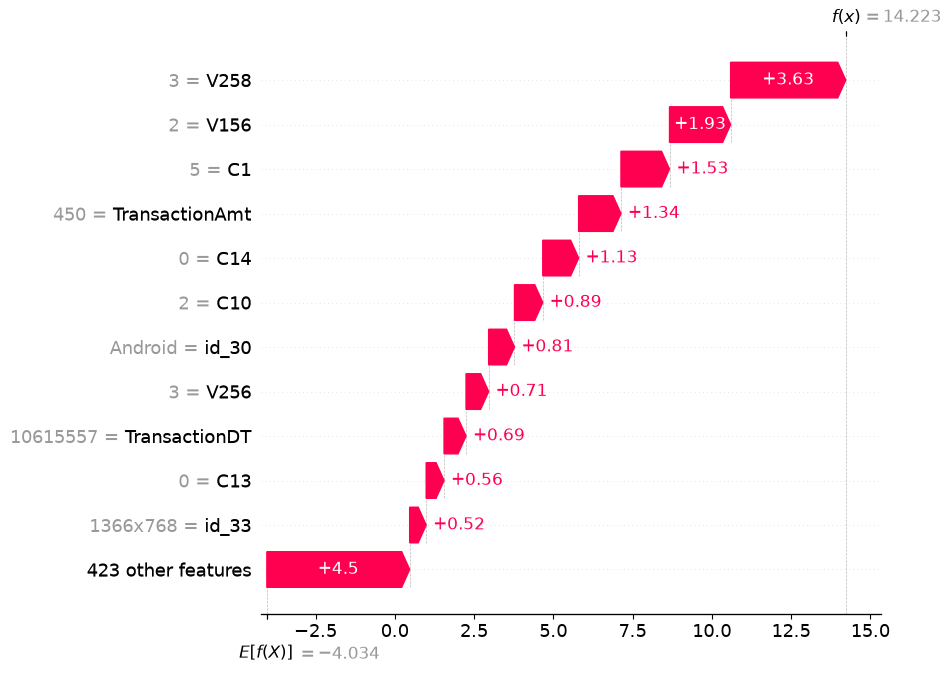

In [5]:
# the 3 highest-scored claims in all of val
top_idx = np.argsort(proba_val)[::-1][:3]
X_top = val[feats].iloc[top_idx]
sv_top = explainer(X_top)

for k in range(3):
    print(f"\nclaim TransactionID={val['TransactionID'].iloc[top_idx[k]]}, "
          f"P(fraud)={proba_val[top_idx[k]]:.3f}, "
          f"actually fraud: {bool(y_val.iloc[top_idx[k]])}")
    shap.plots.waterfall(sv_top[k], max_display=12)


In [ ]:
## Findings

1. **Local accuracy verified numerically**: baseline + Σφ reconstructs the model output
   to 7e-6 across 20k claims. Explanations are exact decompositions, not approximations.
2. **SHAP flagged raw calendar time (`TransactionDT`, mean |φ| 0.32) as the model's #1
   global feature — and the removal experiment kept it.** Hypothesis: a memorized
   "fraud wave" crutch that would age badly. Test: retrain without it. Result: worse in
   the near half (0.598 vs 0.602) AND the far half (0.533 vs 0.545), with slightly
   faster decay (+0.066 vs +0.057). Recent fraud intensity is real signal at this
   horizon. Hypothesis refuted; feature retained; caveat — beyond the data window all
   future timestamps fall past the trees' last split, so long-horizon value is
   untestable here (argues for retraining cadence, not removal).
3. **Explainability ceiling quantified**: ~3 of the top-10 global features are
   investigator-readable (TransactionAmt, card6, P_emaildomain); the anonymized V*/C*
   columns carry the largest per-claim pushes. Motivates porting to a named-feature
   insurance dataset.
4. **Per-claim waterfalls work as a product**: top-3 shortlist claims are all true fraud
   at P≈1.0, each with a feature-level argument (incl. counter-evidence bars).
5. **Explanations revealed a linked fraud burst**: two of the top three claims share
   device, amount, email domain and near-consecutive IDs. The full pattern
   (device + amount) matches 6 validation claims — **100% of them fraud**. Same-actor
   cluster, surfaced by near-identical SHAP signatures.
6. No smoking-gun label proxy: influence is diffuse (415 tail features sum to +3.04,
   larger than any single feature).
